# 16 Transit Investment ROI Analysis

## Purpose

This notebook evaluates which Houston METRO corridors may deserve future transit investment.

Earlier notebooks measured ridership, route productivity, population density, accessibility, and equity-related transit gaps. This notebook combines those outputs into a corridor-level investment screening framework.

## Research Question

Which corridors should METRO prioritize for future transit investment, and what level of investment appears most appropriate?

## Methodological Note

This is a planning-screening model, not a formal engineering cost-benefit analysis. It is designed to compare corridors using available public data and identify candidates for deeper study.


## 1. Import Libraries

This section imports libraries for tabular analysis, geospatial processing, route geometry construction, and visualization.

In [9]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString

## 2. Load Processed and GTFS Datasets

This notebook uses route productivity from Notebook 13, tract-level accessibility from Notebook 15, and GTFS files for route geometry.

In [10]:
routes = pd.read_csv(
    "../data/raw/metro_gtfs/merged/routes.txt"
)

efficiency = pd.read_csv(
    "../data/processed/route_efficiency_summary.csv"
)

access = gpd.read_file(
    "../data/processed/transit_accessibility_index_v2.geojson"
)

trips = pd.read_csv(
    "../data/raw/metro_gtfs/merged/trips.txt"
)

shapes = pd.read_csv(
    "../data/raw/metro_gtfs/merged/shapes.txt"
)

print("routes:", routes.shape)
print("efficiency:", efficiency.shape)
print("access:", access.shape)
print("trips:", trips.shape)
print("shapes:", shapes.shape)

routes: (116, 9)
efficiency: (90, 8)
access: (1115, 36)
trips: (47160, 11)
shapes: (461952, 5)


## 3. Create Corridor Dataset

For this version of the model, each route is treated as a corridor.

The route ID is converted to a string so it can join consistently with GTFS route IDs later.

In [11]:
corridors = efficiency.copy()

corridors["route_id"] = corridors["route_id"].astype(str)
trips["route_id"] = trips["route_id"].astype(str)

corridors.head()

,route_id,route_name,avg_weekday_boardings,avg_boardings_per_revenue_hour,avg_boardings_per_revenue_mile,avg_saturday_boardings,avg_sunday_boardings,months_observed
0,2,Bellaire,7185.166667,29.880000,2.730000,5446.333333,4390.583333,12
1,3,Langley / Little York,2156.250000,16.979167,1.304167,1740.250000,1465.333333,12
2,4,Beechnut,8093.416667,25.177500,2.008333,5038.583333,4109.750000,12
3,5,Southmore,1195.833333,17.502500,1.488333,697.416667,537.583333,12
4,6,Jensen / Greens,3836.166667,20.087500,1.374167,2808.833333,2283.250000,12


## 4. Calculate Demand Score

Demand combines total ridership and productivity.

This prevents the model from only rewarding the routes with the most riders. A corridor scores higher when it has both strong weekday ridership and strong ridership productivity.


In [12]:
def normalize(series):
    denominator = series.max() - series.min()

    if denominator == 0:
        return series * 0

    return (
        series - series.min()
    ) / denominator


if "productivity_score" not in corridors.columns:
    corridors["productivity_score"] = (
        corridors["avg_boardings_per_revenue_hour"]
        *
        corridors["avg_boardings_per_revenue_mile"]
    )

corridors["ridership_score"] = normalize(
    corridors["avg_weekday_boardings"]
)

corridors["productivity_score_norm"] = normalize(
    corridors["productivity_score"]
)

corridors["demand_score"] = (
    0.5 * corridors["ridership_score"]
    +
    0.5 * corridors["productivity_score_norm"]
)

corridors[
    [
        "route_name",
        "avg_weekday_boardings",
        "productivity_score",
        "demand_score"
    ]
].head()

,route_name,avg_weekday_boardings,productivity_score,demand_score
0,Bellaire,7185.166667,81.572400,0.624419
1,Langley / Little York,2156.250000,22.143663,0.175952
2,Beechnut,8093.416667,50.564812,0.523709
3,Southmore,1195.833333,26.049554,0.156715
4,Jensen / Greens,3836.166667,27.603573,0.263111


## 5. Build Route-to-Shape Lookup

GTFS stores route geometry indirectly.

A route has trips, and each trip is associated with a shape. This step creates the missing `route_shapes` table before it is used later in the notebook.


In [13]:
route_shapes = (
    trips[
        [
            "route_id",
            "shape_id"
        ]
    ]
    .dropna()
    .drop_duplicates()
)

route_shapes["route_id"] = route_shapes["route_id"].astype(str)

print(route_shapes.shape)

route_shapes.head()

(660, 2)


,route_id,shape_id
0,500,284553
1,54,284273
2,44,284248
3,153,282502
4,161,282503


## 6. Build Route Line Geometries

GTFS `shapes.txt` stores route geometry as ordered points.

This step converts each shape into a `LineString` geometry so routes can be buffered and spatially joined to census tracts.


In [14]:
route_lines = []

for shape_id, group in shapes.groupby("shape_id"):

    group = group.sort_values(
        "shape_pt_sequence"
    )

    coords = list(
        zip(
            group["shape_pt_lon"],
            group["shape_pt_lat"]
        )
    )

    if len(coords) >= 2:
        route_lines.append(
            {
                "shape_id": shape_id,
                "geometry": LineString(coords)
            }
        )

route_lines = gpd.GeoDataFrame(
    route_lines,
    crs="EPSG:4326"
)

print(route_lines.shape)

route_lines.head()

(694, 2)


,shape_id,geometry
0,282295,"LINESTRING (-95.62941 29.71142, -95.62937 29.7..."
1,282296,"LINESTRING (-95.40328 29.70438, -95.40317 29.7..."
2,282297,"LINESTRING (-95.35836 29.77178, -95.3589 29.77..."
3,282298,"LINESTRING (-95.4716 29.86735, -95.47134 29.86..."
4,282299,"LINESTRING (-95.62941 29.71142, -95.62937 29.7..."


## 7. Join Routes to Line Geometries

The route-to-shape lookup is merged with the route line geometries.

This creates a spatial representation of each route corridor.


In [15]:
route_geometries = (
    route_shapes
    .merge(
        route_lines,
        on="shape_id",
        how="left"
    )
)

route_geometries = gpd.GeoDataFrame(
    route_geometries,
    geometry="geometry",
    crs="EPSG:4326"
)

route_geometries = route_geometries.dropna(
    subset=["geometry"]
)

print(route_geometries.shape)

route_geometries.head()

(660, 3)


,route_id,shape_id,geometry
0,500,284553,"LINESTRING (-95.32329 29.9868, -95.32297 29.98..."
1,54,284273,"LINESTRING (-95.37128 29.7503, -95.37157 29.74..."
2,44,284248,"LINESTRING (-95.57719 29.99338, -95.57659 29.9..."
3,153,282502,"LINESTRING (-95.55987 29.73701, -95.55979 29.7..."
4,161,282503,"LINESTRING (-95.56034 29.65526, -95.56022 29.6..."


## 8. Project Layers and Create Route Buffers

Both route geometries and tract accessibility data are projected to EPSG:3857 so distances and buffers are measured in meters.

An 800-meter buffer approximates the area within walking distance of each route.


In [16]:
route_geometries_projected = route_geometries.to_crs(
    "EPSG:3857"
)

access_projected = access.to_crs(
    "EPSG:3857"
)

route_buffers = route_geometries_projected.copy()

route_buffers["geometry"] = (
    route_buffers.geometry.buffer(800)
)

print(route_buffers.shape)

(660, 3)


## 9. Spatially Join Route Buffers to Census Tracts

This step identifies which census tracts intersect each route buffer.

It allows each route to inherit tract-level context from the accessibility index.


In [17]:
route_tracts = gpd.sjoin(
    route_buffers,
    access_projected,
    how="left",
    predicate="intersects"
)

print(route_tracts.shape)

route_tracts.head()

(31287, 39)


,route_id,shape_id,geometry,index_right,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,...,high_productivity_routes_nearby,high_productivity_score_sum,distance_to_rail_m,stop_count_score,route_frequency_score,high_productivity_route_score,rail_access_score,accessibility_score_v2,density_score,underserved_score_v2
0,500,284553,"POLYGON ((-10617360.172 3472157.937, -10617352...",777,48,201,333302,48201333302,1400000US48201333302,3333.02,...,0.0,0.0,11109.077656,0.0,0.0,0.0,0.0,0.0,0.024784,0.024784
0,500,284553,"POLYGON ((-10617360.172 3472157.937, -10617352...",114,48,201,980000,48201980000,1400000US48201980000,9800,...,0.0,0.0,8872.211851,0.0,0.0,0.0,0.0,0.0,0.000105,0.000105
0,500,284553,"POLYGON ((-10617360.172 3472157.937, -10617352...",192,48,201,320901,48201320901,1400000US48201320901,3209.01,...,0.0,0.0,11665.126164,0.0,0.0,0.0,0.0,0.0,0.144980,0.144980
0,500,284553,"POLYGON ((-10617360.172 3472157.937, -10617352...",824,48,201,333204,48201333204,1400000US48201333204,3332.04,...,0.0,0.0,7971.580161,0.0,0.0,0.0,0.0,0.0,0.557849,0.557849
0,500,284553,"POLYGON ((-10617360.172 3472157.937, -10617352...",713,48,201,333203,48201333203,1400000US48201333203,3332.03,...,0.0,0.0,9027.693382,0.0,0.0,0.0,0.0,0.0,0.050421,0.050421


## 10. Calculate Corridor Context Metrics

For each route, the notebook calculates:

- Average underserved score
- Average accessibility score
- Estimated population exposure
- Average distance to rail

These values make the investment model spatially specific rather than relying on countywide averages.


In [18]:
corridor_context = (
    route_tracts
    .groupby("route_id")
    .agg(
        route_equity_score=(
            "underserved_score_v2",
            "mean"
        ),
        route_accessibility_score=(
            "accessibility_score_v2",
            "mean"
        ),
        population_served=(
            "population",
            "sum"
        ),
        rail_gap_score=(
            "distance_to_rail_m",
            "mean"
        )
    )
    .reset_index()
)

corridor_context["route_id"] = corridor_context["route_id"].astype(str)

corridor_context.head()

,route_id,route_equity_score,route_accessibility_score,population_served,rail_gap_score
0,10,0.113684,0.067702,483902,5573.192590
1,102,0.102633,0.086951,2336432,7198.542473
2,108,0.099878,0.145317,1171362,2407.694774
3,11,0.099631,0.135753,1076994,2616.967334
4,137,0.107079,0.103681,819226,5325.165330


## 11. Merge Corridor Context into the Investment Dataset

This merge adds spatial context to the route productivity table.

At this point, each corridor has demand, productivity, equity, accessibility, rail proximity, and population exposure metrics.


In [19]:
corridors = corridors.merge(
    corridor_context,
    on="route_id",
    how="left"
)

corridors[
    [
        "route_name",
        "route_equity_score",
        "route_accessibility_score",
        "population_served",
        "rail_gap_score"
    ]
].describe()

,route_equity_score,route_accessibility_score,population_served,rail_gap_score
count,79.000000,79.000000,7.900000e+01,79.000000
mean,0.107503,0.055131,7.811594e+05,8616.908868
std,0.045282,0.048454,5.814239e+05,5174.148665
min,0.036100,0.000000,1.437480e+05,1636.758726
25%,0.080380,0.000418,4.302380e+05,4316.636229
50%,0.099063,0.047843,5.939040e+05,8696.396673
75%,0.115246,0.087423,9.296190e+05,10748.793573
max,0.253514,0.168162,3.548012e+06,26386.136688


## 12. Calculate Investment Priority Score

The investment priority score combines five components:

| Component | Weight |
|---|---:|
| Demand Score | 30% |
| Equity Score | 20% |
| Rail Gap Score | 15% |
| Accessibility Need | 15% |
| Population Exposure | 20% |

Higher values indicate corridors that combine strong demand, important equity context, weaker existing accessibility, and limited proximity to rail.


In [20]:
population_score = normalize(
    corridors["population_served"].fillna(0)
)

equity_score = normalize(
    corridors["route_equity_score"].fillna(0)
)

rail_gap_score_norm = normalize(
    corridors["rail_gap_score"].fillna(0)
)

accessibility_need = (
    1 -
    normalize(
        corridors["route_accessibility_score"].fillna(0)
    )
)

corridors["investment_priority"] = (
    0.30 * corridors["demand_score"]
    +
    0.20 * equity_score
    +
    0.15 * rail_gap_score_norm
    +
    0.15 * accessibility_need
    +
    0.20 * population_score
)

corridors[
    [
        "route_name",
        "investment_priority",
        "demand_score",
        "route_equity_score",
        "route_accessibility_score",
        "rail_gap_score",
        "population_served"
    ]
].sort_values(
    "investment_priority",
    ascending=False
).head(25)

,route_name,investment_priority,demand_score,route_equity_score,route_accessibility_score,rail_gap_score,population_served
72,Harwin Express,0.619929,0.276167,0.180608,0.032918,13009.767023,3548012.0
55,Westheimer,0.601180,0.776263,0.169695,0.047239,11465.913102,1088928.0
40,Fondren,0.585410,0.671342,0.167254,0.000000,12460.784805,553884.0
28,Gessner,0.584972,0.669133,0.123084,0.000000,16261.835335,792716.0
29,Hillcroft,0.555218,0.390269,0.204404,0.000000,10613.475510,1180520.0
0,Bellaire,0.539828,0.624419,0.153127,0.038685,11786.259082,872866.0
13,Richmond,0.510331,0.465892,0.156028,0.067694,8696.396673,1923344.0
42,Bissonnet,0.497552,0.523785,0.144808,0.047646,10988.261221,997166.0
71,Harwin Express,0.494793,0.224629,0.194191,0.041296,9685.885978,1880068.0
2,Beechnut,0.494773,0.523709,0.126932,0.071980,10446.741052,1638134.0


## 13. Rank Investment Corridors

This table ranks the strongest corridors according to the final investment priority score.


In [21]:
top_corridors = corridors[
    [
        "route_name",
        "investment_priority",
        "demand_score",
        "route_equity_score",
        "route_accessibility_score",
        "rail_gap_score",
        "population_served"
    ]
].sort_values(
    "investment_priority",
    ascending=False
).copy()

top_corridors.head(25)

,route_name,investment_priority,demand_score,route_equity_score,route_accessibility_score,rail_gap_score,population_served
72,Harwin Express,0.619929,0.276167,0.180608,0.032918,13009.767023,3548012.0
55,Westheimer,0.601180,0.776263,0.169695,0.047239,11465.913102,1088928.0
40,Fondren,0.585410,0.671342,0.167254,0.000000,12460.784805,553884.0
28,Gessner,0.584972,0.669133,0.123084,0.000000,16261.835335,792716.0
29,Hillcroft,0.555218,0.390269,0.204404,0.000000,10613.475510,1180520.0
0,Bellaire,0.539828,0.624419,0.153127,0.038685,11786.259082,872866.0
13,Richmond,0.510331,0.465892,0.156028,0.067694,8696.396673,1923344.0
42,Bissonnet,0.497552,0.523785,0.144808,0.047646,10988.261221,997166.0
71,Harwin Express,0.494793,0.224629,0.194191,0.041296,9685.885978,1880068.0
2,Beechnut,0.494773,0.523709,0.126932,0.071980,10446.741052,1638134.0


## 14. Classify Investment Tiers

Numeric scores are translated into broad planning tiers so the results are easier to interpret.


In [22]:
top_corridors["investment_tier"] = pd.cut(
    top_corridors["investment_priority"],
    bins=[0, 0.35, 0.50, 0.65, 1],
    labels=[
        "Low Priority",
        "Moderate Priority",
        "High Priority",
        "Flagship Corridor"
    ]
)

top_corridors[
    [
        "route_name",
        "investment_priority",
        "investment_tier"
    ]
].head(25)

,route_name,investment_priority,investment_tier
72,Harwin Express,0.619929,High Priority
55,Westheimer,0.601180,High Priority
40,Fondren,0.585410,High Priority
28,Gessner,0.584972,High Priority
29,Hillcroft,0.555218,High Priority
0,Bellaire,0.539828,High Priority
13,Richmond,0.510331,High Priority
42,Bissonnet,0.497552,Moderate Priority
71,Harwin Express,0.494793,Moderate Priority
2,Beechnut,0.494773,Moderate Priority


## 15. Recommend Investment Type

This step translates the investment priority score into broad screening recommendations.

These are not final engineering decisions. They are planning categories for further study.


In [23]:
def recommend_investment(score):

    if score >= 0.55:
        return "Rail / BRT Candidate"

    elif score >= 0.45:
        return "BRT Candidate"

    else:
        return "Enhanced Bus Service"


top_corridors["recommended_investment"] = (
    top_corridors["investment_priority"]
    .apply(recommend_investment)
)

top_corridors[
    [
        "route_name",
        "investment_priority",
        "investment_tier",
        "recommended_investment"
    ]
].head(25)

,route_name,investment_priority,investment_tier,recommended_investment
72,Harwin Express,0.619929,High Priority,Rail / BRT Candidate
55,Westheimer,0.601180,High Priority,Rail / BRT Candidate
40,Fondren,0.585410,High Priority,Rail / BRT Candidate
28,Gessner,0.584972,High Priority,Rail / BRT Candidate
29,Hillcroft,0.555218,High Priority,Rail / BRT Candidate
0,Bellaire,0.539828,High Priority,BRT Candidate
13,Richmond,0.510331,High Priority,BRT Candidate
42,Bissonnet,0.497552,Moderate Priority,BRT Candidate
71,Harwin Express,0.494793,Moderate Priority,BRT Candidate
2,Beechnut,0.494773,Moderate Priority,BRT Candidate


## 16. Visualize Top Investment Corridors

This chart shows the top corridors by investment priority score.


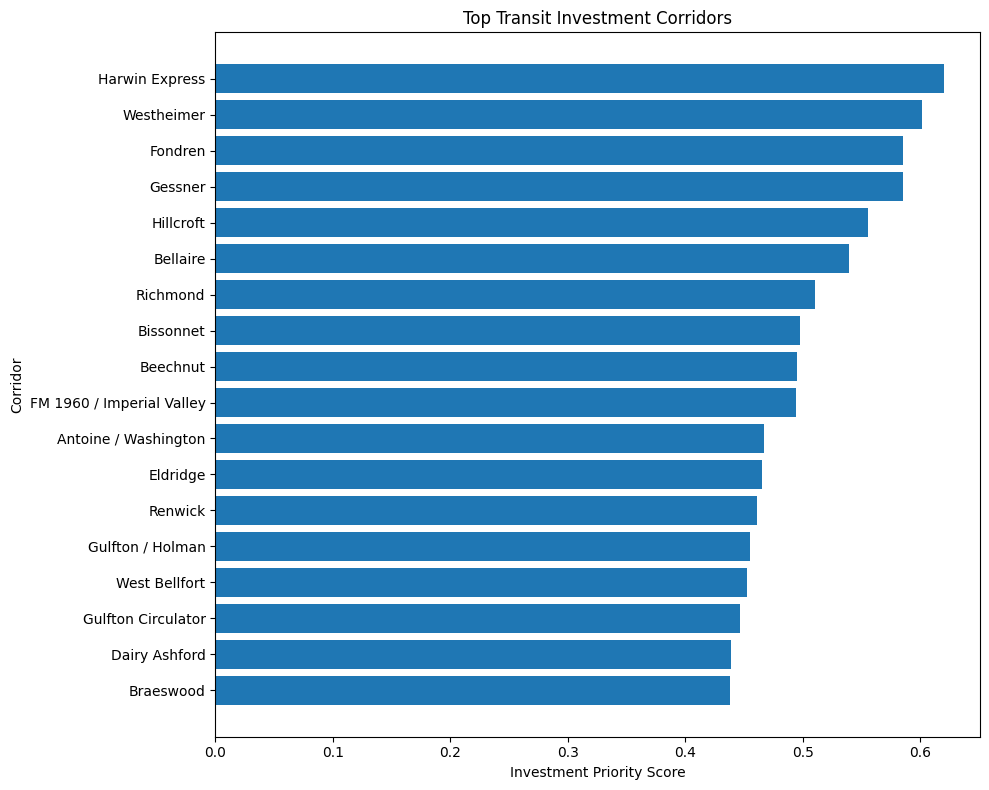

In [24]:
top20 = top_corridors.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["route_name"],
    top20["investment_priority"]
)

plt.gca().invert_yaxis()

plt.title("Top Transit Investment Corridors")
plt.xlabel("Investment Priority Score")
plt.ylabel("Corridor")

plt.tight_layout()
plt.show()

## 17. Save Final Investment Analysis

The final output is saved with the investment tier and recommended investment fields included.

This file is used by Notebook 17.


In [25]:
top_corridors.to_csv(
    "../data/processed/transit_investment_roi_analysis.csv",
    index=False
)

print("saved")

saved


## Summary

This notebook creates a corridor-level transit investment screening model for Houston METRO.

The model combines route productivity, route geography, census tract accessibility, equity need, population exposure, and rail proximity into a single investment priority score.

## Key Interpretation

The strongest candidates are not simply the routes with the highest ridership. Strong candidates are corridors that combine:

- High demand
- Efficient service performance
- Exposure to underserved areas
- Lower existing accessibility
- Greater distance from current rail service

## Limitations

This is a planning-screening model, not a formal engineering or financial cost-benefit analysis.

Important limitations include:

- Route buffers approximate access and do not use the pedestrian street network
- Population served may double-count overlapping tract exposure
- Capital cost estimates are represented indirectly through investment categories
- Rail recommendations require engineering, right-of-way, political, and funding analysis
- The model does not yet include employment density, zero-vehicle households, or travel-time savings

Despite those limitations, the notebook provides a transparent and defensible way to compare corridors using available public data.
